In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# 1. 데이터 불러오기 (한글 인코딩)
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt로 시간 분해
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. 파생 변수 생성
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)

# 4. 과거 시계열 특성 생성
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)

for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)

# 5. 결측치 제거
df_model = df_long.dropna().copy()

# 6. 피처 및 타겟 설정
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

X = df_model[features]
y = df_model[target]

# 7. 학습/검증 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 8. XGBoost 모델 학습
model = XGBRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 9. 예측 및 평가
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ MAPE: {mape:.4f}")


✅ RMSE: 3747.80
✅ MAPE: 0.0400


/Users/jeonjunhyeok/Desktop/Lab/ML/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjunhyeok/Desktop/Lab/ML/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47141 (\N{HANGUL SYLLABLE RYEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjunhyeok/Desktop/Lab/ML/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjunhyeok/Desktop/Lab/ML/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjunhyeok/Desktop/Lab/ML/venv/lib/python3.13/site-packages/IPython/core/pylab

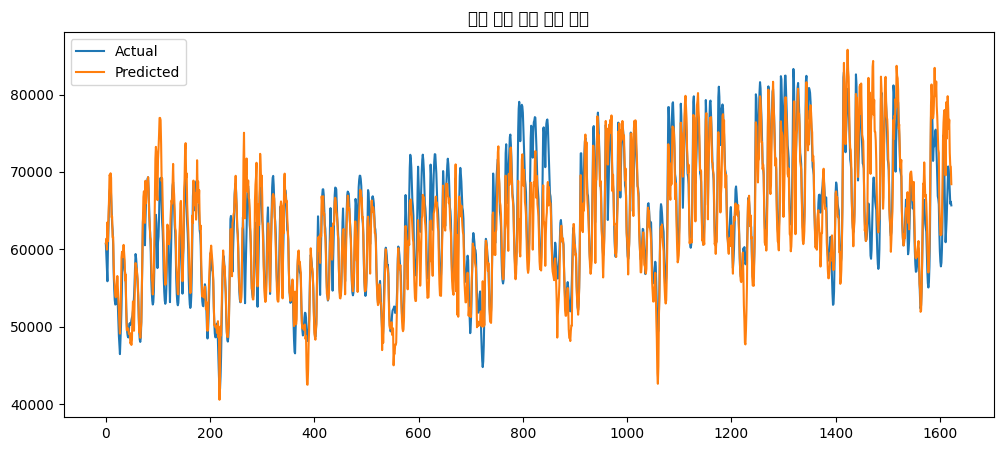

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Predict Comparison")
plt.show()

In [7]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore

# 1. 데이터 불러오기
df = pd.read_csv("./archive/한국전력거래소_시간별 전국 전력수요량_20241231.csv", encoding="euc-kr")

# 2. melt
df_long = df.melt(id_vars=["날짜"], var_name="hour", value_name="DEMAND")
df_long["hour"] = df_long["hour"].str.replace("시", "").astype(int) - 1
df_long["datetime"] = pd.to_datetime(df_long["날짜"]) + pd.to_timedelta(df_long["hour"], unit="h")

# 3. 파생 변수
df_long["hourOfDay"] = df_long["datetime"].dt.hour
df_long["dayOfWeek"] = df_long["datetime"].dt.dayofweek
df_long["weekend"] = (df_long["dayOfWeek"] >= 5).astype(int)

# 4. 시계열 특성 생성
df_long.sort_values("datetime", inplace=True)
df_long.reset_index(drop=True, inplace=True)

for i in range(1, 5):
    df_long[f"week_X-{i}"] = df_long["DEMAND"].shift(24 * 7 * i)
df_long["MA_X-4"] = df_long[[f"week_X-{i}" for i in range(1, 5)]].mean(axis=1)

# 5. 결측치 제거
df_model = df_long.dropna().copy()

# ✅ 6. 이상치 탐지 (z-score 기준)
z_scores = zscore(df_model[["DEMAND"]])
df_model["zscore"] = z_scores
df_model_no_outlier = df_model[df_model["zscore"].abs() <= 2].copy()

# 7. 학습
features = ["week_X-1", "week_X-2", "week_X-3", "week_X-4", "MA_X-4", "hourOfDay", "dayOfWeek", "weekend"]
target = "DEMAND"

X = df_model_no_outlier[features]
y = df_model_no_outlier[target]

# 모델 학습
model_clean = XGBRegressor(n_estimators=100, random_state=42)
model_clean.fit(X_train, y_train)

# 예측 및 평가
y_pred = model_clean.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"✅ [이상치 제거 후] RMSE: {rmse:.2f}")
print(f"✅ [이상치 제거 후] MAPE: {mape:.4f}")


✅ [이상치 제거 후] RMSE: 3727.19
✅ [이상치 제거 후] MAPE: 0.0399


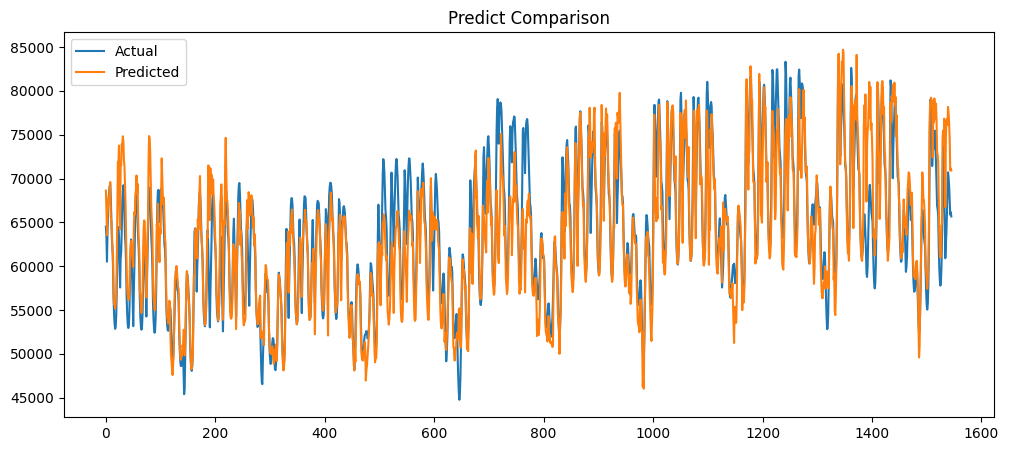

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Predict Comparison")
plt.show()